In [1]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [2]:
import shutil
from datasets import load_dataset

free_gb = shutil.disk_usage("/").free / 1e9
print(f"Free disk space: {free_gb:.1f} GB")
assert free_gb > 5, "Under 5GB free — clear space before continuing (see huggingface-cli delete-cache)"

hotpot = load_dataset(
    "hotpotqa/hotpot_qa",
    split="validation[:200]",
    revision="refs/convert/parquet",
)

nq = load_dataset(
    "google-research-datasets/nq_open",
    split="validation[:200]",
)

print("HotpotQA:", len(hotpot), "examples")
print("NQ:", len(nq), "examples")
print("\nHotpotQA sample:", hotpot[0])
print("\nNQ sample:", nq[0])

Free disk space: 8.5 GB


HotpotQA: 200 examples
NQ: 200 examples

HotpotQA sample: {'id': '5a8b57f25542995d1e6f1371', 'question': 'Were Scott Derrickson and Ed Wood of the same nationality?', 'answer': 'yes', 'type': 'comparison', 'level': 'hard', 'supporting_facts': {'title': ['Scott Derrickson', 'Ed Wood'], 'sent_id': [0, 0]}, 'context': {'title': ['Ed Wood (film)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)'], 'sentences': [['Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.', " The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.", ' Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.'], ['Scott Derrickson

In [3]:
import sys
sys.path.append("..")  # so we can import from the project root

import random
import json
from perturbations.generators import (
    inject_contradiction,
    inject_lexical_distractor,
    inject_stale_document,
    inject_multihop_gap,
    inject_topical_noise,
)

rng = random.Random(42)  # fixed seed for reproducibility
hotpot_list = list(hotpot)  # convert HF Dataset to plain list of dicts, easier to work with

PERTURBATIONS = {
    "contradiction": inject_contradiction,
    "lexical_distractor": inject_lexical_distractor,
    "stale_document": inject_stale_document,
    "multihop_gap": inject_multihop_gap,
    "topical_noise": inject_topical_noise,
}

stress_test_suite = []
for example in hotpot_list:
    for name, fn in PERTURBATIONS.items():
        perturbed = fn(example, corpus_pool=hotpot_list, rng=rng)
        stress_test_suite.append(perturbed)

print(f"Built {len(stress_test_suite)} stress-test examples "
      f"({len(hotpot_list)} originals x {len(PERTURBATIONS)} perturbation types)")

# Quick sanity check: print one example per perturbation type
seen_types = set()
for ex in stress_test_suite:
    if ex["perturbation_type"] not in seen_types:
        seen_types.add(ex["perturbation_type"])
        print(f"\n=== {ex['perturbation_type']} ===")
        print("Question:", ex["question"])
        print("Answer:", ex["answer"])
        print("Context titles:", ex["context"]["title"])

# Save to disk so later phases don't need to regenerate this
with open("../data/datasets/stress_test_suite.json", "w") as f:
    json.dump(stress_test_suite, f, indent=2)
print("\nSaved to data/datasets/stress_test_suite.json")

Built 1000 stress-test examples (200 originals x 5 perturbation types)

=== contradiction ===
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Answer: yes
Context titles: ['Ed Wood (film)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)']

=== lexical_distractor ===
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Answer: yes
Context titles: ['Gone in 60 Seconds (2000 film) (lexical distractor)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)']

=== stale_document ===
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Answer: yes
Context titles: ['Ed Wood (film)', 'Scott Derrickson (2010 archive)', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Ev

In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # downloads once, ~90MB, cached locally


def build_local_index(example: dict):
    """Build a small FAISS index over just this example's candidate passages."""
    passages = ["".join(sents) for sents in example["context"]["sentences"]]
    titles = example["context"]["title"]

    embeddings = embed_model.encode(passages, convert_to_numpy=True, normalize_embeddings=True)
    index = faiss.IndexFlatIP(embeddings.shape[1])  # inner product on normalized vectors = cosine similarity
    index.add(embeddings)
    return index, titles, passages


def retrieve_top_k(example: dict, k: int = 3):
    """Embed the question, search this example's local index, return top-k (title, passage, score)."""
    index, titles, passages = build_local_index(example)
    query_vec = embed_model.encode([example["question"]], convert_to_numpy=True, normalize_embeddings=True)
    scores, indices = index.search(query_vec, k)
    return [(titles[i], passages[i], float(scores[0][j])) for j, i in enumerate(indices[0])]


# Sanity check: run retrieval on the first contradiction example and inspect
sample = stress_test_suite[0]
print("Question:", sample["question"])
print("Gold titles:", sample["supporting_facts"]["title"])
print("\nTop-3 retrieved:")
for title, passage, score in retrieve_top_k(sample, k=3):
    print(f"  [{score:.3f}] {title}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold titles: ['Scott Derrickson', 'Ed Wood']

Top-3 retrieved:
  [0.503] Scott Derrickson
  [0.494] Ed Wood (film)
  [0.486] Ed Wood


In [5]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")

device = "cuda" if torch.cuda.is_available() else "cpu"
gen_model = gen_model.to(device)
print("Using device:", device)


PROMPT_TEMPLATE = """Answer the question using ONLY the context below. If the context does not contain the answer, say "unknown".

Context:
{context}

Question: {question}
Answer:"""


def generate_answer(question: str, retrieved_passages: list[tuple[str, str, float]]) -> str:
    context_text = "\n".join(f"- {title}: {passage}" for title, passage, _ in retrieved_passages)
    prompt = PROMPT_TEMPLATE.format(context=context_text, question=question)

    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = gen_model.generate(**inputs, max_new_tokens=32)
    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)


sample = stress_test_suite[0]
retrieved = retrieve_top_k(sample, k=3)
predicted_answer = generate_answer(sample["question"], retrieved)

print("Question:", sample["question"])
print("Gold answer:", sample["answer"])
print("Predicted answer:", predicted_answer)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Using device: cpu
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold answer: yes
Predicted answer: no


In [6]:
import sys
sys.path.append("..")
from evaluation.metrics.qa_metrics import exact_match, f1_score, retrieval_recall
import time

results = []
start = time.time()

for i, example in enumerate(stress_test_suite):
    retrieved = retrieve_top_k(example, k=3)
    retrieved_titles = [title for title, _, _ in retrieved]
    predicted = generate_answer(example["question"], retrieved)

    gold_answer = example["answer"]
    gold_titles = list(example["supporting_facts"]["title"])

    results.append({
        "id": example["id"],
        "perturbation_type": example["perturbation_type"],
        "question": example["question"],
        "gold_answer": gold_answer,
        "predicted_answer": predicted,
        "em": exact_match(predicted, gold_answer),
        "f1": f1_score(predicted, gold_answer),
        "retrieval_recall": retrieval_recall(retrieved_titles, gold_titles),
    })

    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        print(f"  {i + 1}/{len(stress_test_suite)} done ({elapsed:.0f}s elapsed)")

print(f"\nTotal time: {time.time() - start:.0f}s")

import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv("../results/baseline_results.csv", index=False)

summary = results_df.groupby("perturbation_type")[["em", "f1", "retrieval_recall"]].mean()
print("\n=== Baseline RAG performance by failure mode ===")
print(summary)

  100/1000 done (49s elapsed)
  200/1000 done (98s elapsed)
  300/1000 done (151s elapsed)
  400/1000 done (200s elapsed)
  500/1000 done (248s elapsed)
  600/1000 done (301s elapsed)
  700/1000 done (353s elapsed)
  800/1000 done (417s elapsed)
  900/1000 done (469s elapsed)
  1000/1000 done (527s elapsed)

Total time: 527s

=== Baseline RAG performance by failure mode ===
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.190  0.264820          0.617500
lexical_distractor  0.245  0.322931          0.614167
multihop_gap        0.170  0.227355          0.342583
stale_document      0.225  0.303148          0.604167
topical_noise       0.255  0.342026          0.620833


C:\Users\Avahan  Masih\AppData\Local\Temp\ipykernel_27920\2788803004.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(summary.index, rotation=30, ha="right")


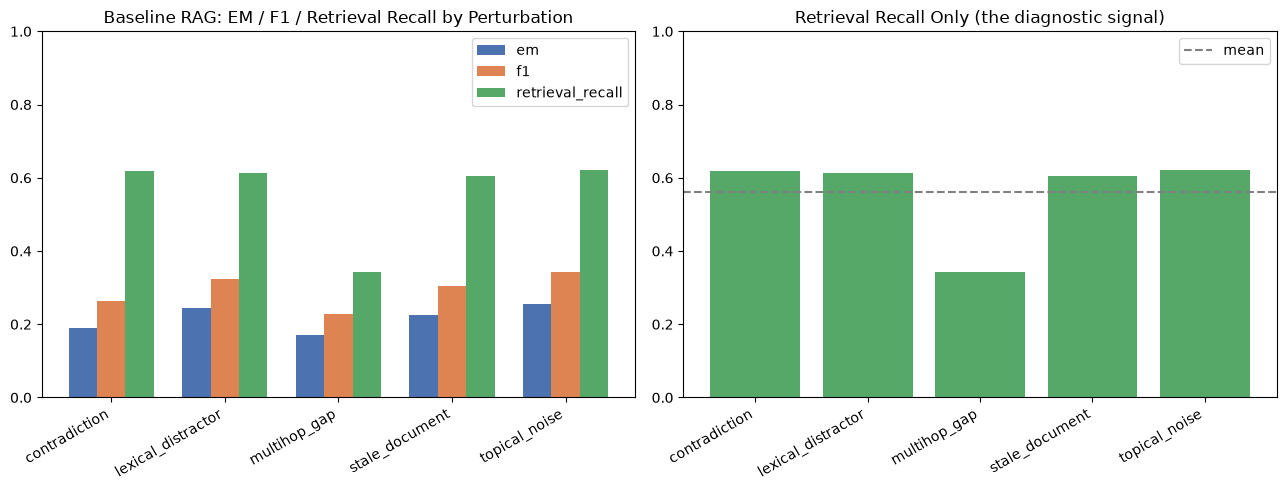

Saved to results/baseline_by_perturbation.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ["em", "f1", "retrieval_recall"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
x = np.arange(len(summary.index))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, summary[metric], width, label=metric, color=colors[i])
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(summary.index, rotation=30, ha="right")
axes[0].set_title("Baseline RAG: EM / F1 / Retrieval Recall by Perturbation")
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(summary.index, summary["retrieval_recall"], color="#55A868")
axes[1].axhline(summary["retrieval_recall"].mean(), color="gray", linestyle="--", label="mean")
axes[1].set_title("Retrieval Recall Only (the diagnostic signal)")
axes[1].set_xticklabels(summary.index, rotation=30, ha="right")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../results/baseline_by_perturbation.png", dpi=150)
plt.show()
print("Saved to results/baseline_by_perturbation.png")

In [8]:
# Check: does the injected perturbation passage ever land in top-3 retrieved?
injected_hit_count = 0
checked = 0

for ex in stress_test_suite:
    if ex["perturbation_type"] not in ("lexical_distractor", "topical_noise"):
        continue
    checked += 1
    retrieved = retrieve_top_k(ex, k=3)
    retrieved_titles = [t for t, _, _ in retrieved]
    # our injected passages carry a marker suffix like "(lexical distractor)" / "(noise)"
    if any("(lexical distractor)" in t or "(noise)" in t for t in retrieved_titles):
        injected_hit_count += 1

print(f"Injected passage appeared in top-3 for {injected_hit_count}/{checked} examples "
      f"({100*injected_hit_count/checked:.1f}%)")

Injected passage appeared in top-3 for 6/400 examples (1.5%)


In [9]:
import inspect
from perturbations import generators
print(inspect.getsource(generators.inject_lexical_distractor))

def inject_lexical_distractor(example: dict, corpus_pool: list[dict], **_) -> dict:
    """
    Failure mode: LEXICAL SIMILARITY DISTRACTOR.
    Finds a passage from elsewhere in the corpus that shares many keywords
    with the question but answers a DIFFERENT question, and REPLACES the
    least-relevant existing non-gold passage in the pool with it.

    NOTE (design iteration): this used to *append* the distractor as an
    extra candidate. Empirically, that intrusion rate into top-3 retrieval
    was ~1.2% at k=3 with a ~10-passage pool — the appended passage almost
    never displaced anything, making the perturbation a near no-op. We now
    replace the weakest-relevance non-gold passage instead, guaranteeing
    the distractor actually competes for a retrieval slot, while still
    never evicting a gold passage (so the task stays solvable in principle).
    """
    new_example = _deep_copy_example(example)
    gold_titles = _gold_titles(new_example)
    question_keywords = set(

In [10]:
import numpy as np

overlap_scores = []
ranks = []

for ex in stress_test_suite:
    if ex["perturbation_type"] != "lexical_distractor":
        continue

    overlap_scores.append(ex.get("lexical_distractor_overlap_score", None))

    # find the injected passage and compute its FULL rank (not just top-3 binary)
    index, titles, passages = build_local_index(ex)
    query_vec = embed_model.encode([ex["question"]], convert_to_numpy=True, normalize_embeddings=True)
    scores, indices = index.search(query_vec, len(titles))  # rank ALL passages, not just top-3

    ranked_titles = [titles[i] for i in indices[0]]
    for rank, t in enumerate(ranked_titles):
        if "(lexical distractor)" in t:
            ranks.append(rank)  # 0 = top-ranked, len-1 = last-ranked
            break

overlap_scores = [s for s in overlap_scores if s is not None]
print(f"Overlap score — mean: {np.mean(overlap_scores):.2f}, median: {np.median(overlap_scores):.1f}, "
      f"min: {min(overlap_scores)}, max: {max(overlap_scores)}")
print(f"\nDistractor rank — mean: {np.mean(ranks):.2f} (0=top, ~9=bottom), "
      f"median: {np.median(ranks):.1f}")
print(f"Distractor landed in bottom-3 of ~{np.mean([len(build_local_index(ex)[1]) for ex in stress_test_suite[:20]]):.0f}: "
      f"{sum(1 for r in ranks if r >= 7)}/{len(ranks)}")

Overlap score — mean: 3.97, median: 4.0, min: 1, max: 12

Distractor rank — mean: 7.84 (0=top, ~9=bottom), median: 9.0
Distractor landed in bottom-3 of ~10: 162/200


In [11]:
import numpy as np

overlap_scores = []
ranks = []

for ex in stress_test_suite:
    if ex["perturbation_type"] != "topical_noise":
        continue

    index, titles, passages = build_local_index(ex)
    query_vec = embed_model.encode([ex["question"]], convert_to_numpy=True, normalize_embeddings=True)
    scores, indices = index.search(query_vec, len(titles))

    ranked_titles = [titles[i] for i in indices[0]]
    for rank, t in enumerate(ranked_titles):
        if "(noise)" in t:
            ranks.append(rank)
            break

print(f"Noise rank — mean: {np.mean(ranks):.2f} (0=top, ~9=bottom), median: {np.median(ranks):.1f}")
print(f"Noise landed in bottom-3 of ~10: {sum(1 for r in ranks if r >= 7)}/{len(ranks)}")

Noise rank — mean: 8.78 (0=top, ~9=bottom), median: 9.0
Noise landed in bottom-3 of ~10: 197/200


In [12]:
results = []
start = time.time()

for i, example in enumerate(stress_test_suite):
    retrieved = retrieve_top_k(example, k=3)
    retrieved_titles = [title for title, _, _ in retrieved]
    predicted = generate_answer(example["question"], retrieved)

    results.append({
        "id": example["id"],
        "perturbation_type": example["perturbation_type"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted,
        "em": exact_match(predicted, example["answer"]),
        "f1": f1_score(predicted, example["answer"]),
        "retrieval_recall": retrieval_recall(retrieved_titles, list(example["supporting_facts"]["title"])),
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(stress_test_suite)} done ({time.time() - start:.0f}s elapsed)")

print(f"\nTotal time: {time.time() - start:.0f}s")

results_df = pd.DataFrame(results)
results_df.to_csv("../results/baseline_results.csv", index=False)

summary = results_df.groupby("perturbation_type")[["em", "f1", "retrieval_recall"]].mean()
print("\n=== Corrected baseline RAG performance by failure mode ===")
print(summary)

  100/1000 done (56s elapsed)
  200/1000 done (114s elapsed)
  300/1000 done (175s elapsed)
  400/1000 done (229s elapsed)
  500/1000 done (280s elapsed)
  600/1000 done (334s elapsed)
  700/1000 done (389s elapsed)
  800/1000 done (452s elapsed)
  900/1000 done (506s elapsed)
  1000/1000 done (564s elapsed)

Total time: 564s

=== Corrected baseline RAG performance by failure mode ===
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.190  0.264820          0.617500
lexical_distractor  0.245  0.322931          0.614167
multihop_gap        0.170  0.227355          0.342583
stale_document      0.225  0.303148          0.604167
topical_noise       0.255  0.342026          0.620833


In [13]:
print(len(stress_test_suite))
print(stress_test_suite[0]["question"])

1000
Were Scott Derrickson and Ed Wood of the same nationality?


In [14]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")  # ~80MB, CPU-friendly


def retrieve_and_rerank(example: dict, k_first: int = 10, k_final: int = 3):
    """
    Stage 1: bi-encoder (FAISS) retrieves k_first candidates from the local pool.
    Stage 2: cross-encoder scores each (question, passage) pair jointly and
    re-sorts, keeping only the top k_final.
    """
    index, titles, passages = build_local_index(example)
    query_vec = embed_model.encode([example["question"]], convert_to_numpy=True, normalize_embeddings=True)

    n_first = min(k_first, len(titles))
    _, indices = index.search(query_vec, n_first)
    candidates = [(titles[i], passages[i]) for i in indices[0]]

    pairs = [[example["question"], text] for _, text in candidates]
    rerank_scores = reranker.predict(pairs)

    reranked = sorted(zip(candidates, rerank_scores), key=lambda pair: pair[1], reverse=True)
    top_k = reranked[:k_final]
    return [(title, text, float(score)) for (title, text), score in top_k]


# Sanity check on the same sample we've been tracking since Phase 4
sample = stress_test_suite[0]
print("Question:", sample["question"])
print("Gold titles:", sample["supporting_facts"]["title"])
print("\nTop-3 reranked:")
for title, text, score in retrieve_and_rerank(sample):
    print(f"  [{score:.3f}] {title}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold titles: ['Scott Derrickson', 'Ed Wood']

Top-3 reranked:
  [9.544] Scott Derrickson
  [0.588] Ed Wood (film)
  [-1.593] Ed Wood


In [15]:
import numpy as np

rerank_positions = []

for ex in stress_test_suite:
    if ex["perturbation_type"] != "lexical_distractor":
        continue

    index, titles, passages = build_local_index(ex)
    query_vec = embed_model.encode([ex["question"]], convert_to_numpy=True, normalize_embeddings=True)
    _, indices = index.search(query_vec, len(titles))  # get ALL passages back from stage 1

    candidates = [(titles[i], passages[i]) for i in indices[0]]
    pairs = [[ex["question"], text] for _, text in candidates]
    scores = reranker.predict(pairs)

    reranked = sorted(zip(candidates, scores), key=lambda p: p[1], reverse=True)
    for rank, ((title, _), _) in enumerate(reranked):
        if "(lexical distractor)" in title:
            rerank_positions.append(rank)
            break

print(f"Reranked distractor position — mean: {np.mean(rerank_positions):.2f} (0=top, ~9=bottom), "
      f"median: {np.median(rerank_positions):.1f}")
print(f"Bottom-3 rate: {sum(1 for r in rerank_positions if r >= 7)}/{len(rerank_positions)}")
print(f"Top-3 rate (would this now intrude on generation context?): {sum(1 for r in rerank_positions if r < 3)}/{len(rerank_positions)}")

Reranked distractor position — mean: 8.28 (0=top, ~9=bottom), median: 9.0
Bottom-3 rate: 178/200
Top-3 rate (would this now intrude on generation context?): 4/200


In [16]:
import numpy as np

rerank_positions = []

for ex in stress_test_suite:
    if ex["perturbation_type"] != "topical_noise":
        continue

    index, titles, passages = build_local_index(ex)
    query_vec = embed_model.encode([ex["question"]], convert_to_numpy=True, normalize_embeddings=True)
    _, indices = index.search(query_vec, len(titles))

    candidates = [(titles[i], passages[i]) for i in indices[0]]
    pairs = [[ex["question"], text] for _, text in candidates]
    scores = reranker.predict(pairs)

    reranked = sorted(zip(candidates, scores), key=lambda p: p[1], reverse=True)
    for rank, ((title, _), _) in enumerate(reranked):
        if "(noise)" in title:
            rerank_positions.append(rank)
            break

print(f"Reranked noise position — mean: {np.mean(rerank_positions):.2f}, median: {np.median(rerank_positions):.1f}")
print(f"Bottom-3 rate: {sum(1 for r in rerank_positions if r >= 7)}/{len(rerank_positions)}")
print(f"Top-3 rate: {sum(1 for r in rerank_positions if r < 3)}/{len(rerank_positions)}")

Reranked noise position — mean: 8.89, median: 9.0
Bottom-3 rate: 198/200
Top-3 rate: 1/200


In [17]:
results_reranked = []
start = time.time()

for i, example in enumerate(stress_test_suite):
    retrieved = retrieve_and_rerank(example, k_first=10, k_final=3)
    retrieved_titles = [title for title, _, _ in retrieved]
    predicted = generate_answer(example["question"], retrieved)

    results_reranked.append({
        "id": example["id"],
        "perturbation_type": example["perturbation_type"],
        "em": exact_match(predicted, example["answer"]),
        "f1": f1_score(predicted, example["answer"]),
        "retrieval_recall": retrieval_recall(retrieved_titles, list(example["supporting_facts"]["title"])),
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(stress_test_suite)} done ({time.time() - start:.0f}s elapsed)")

print(f"\nTotal time: {time.time() - start:.0f}s")

reranked_df = pd.DataFrame(results_reranked)
reranked_df.to_csv("../results/reranked_results.csv", index=False)

summary_reranked = reranked_df.groupby("perturbation_type")[["em", "f1", "retrieval_recall"]].mean()
print("\n=== Reranked RAG performance by failure mode ===")
print(summary_reranked)

print("\n=== Bi-encoder baseline (Phase 5) for comparison ===")
print(summary)

print("\n=== Delta (reranked - baseline) ===")
print(summary_reranked - summary)

  100/1000 done (93s elapsed)
  200/1000 done (184s elapsed)
  300/1000 done (282s elapsed)
  400/1000 done (371s elapsed)
  500/1000 done (456s elapsed)
  600/1000 done (546s elapsed)
  700/1000 done (634s elapsed)
  800/1000 done (726s elapsed)
  900/1000 done (812s elapsed)
  1000/1000 done (910s elapsed)

Total time: 910s

=== Reranked RAG performance by failure mode ===
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.230  0.314268          0.695417
lexical_distractor  0.260  0.352268          0.694583
multihop_gap        0.190  0.252725          0.377167
stale_document      0.265  0.343175          0.692917
topical_noise       0.270  0.366490          0.703750

=== Bi-encoder baseline (Phase 5) for comparison ===
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.190  0.264820          0.617500
lexical_distractor  0.245  0

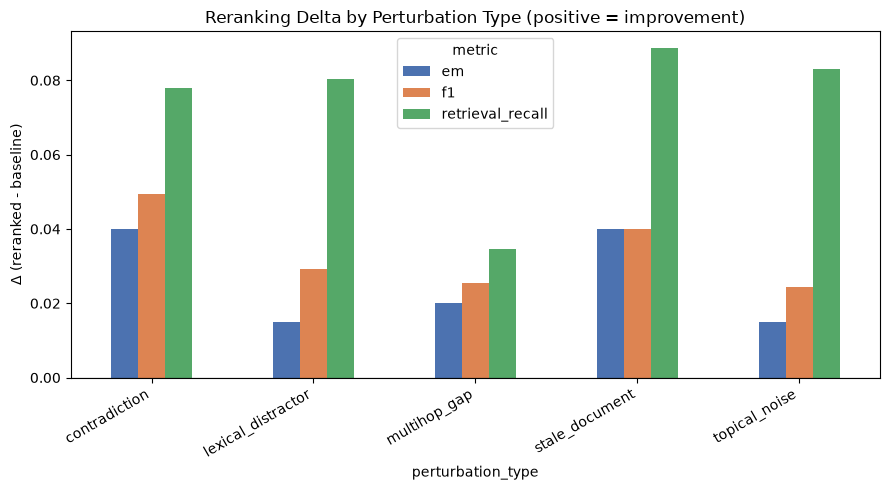

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
delta = summary_reranked - summary
delta[["em", "f1", "retrieval_recall"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Reranking Delta by Perturbation Type (positive = improvement)")
ax.set_ylabel("Δ (reranked - baseline)")
ax.legend(title="metric")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../results/reranking_delta.png", dpi=150)
plt.show()

In [19]:
print(len(stress_test_suite))
print(summary_reranked)

1000
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.230  0.314268          0.695417
lexical_distractor  0.260  0.352268          0.694583
multihop_gap        0.190  0.252725          0.377167
stale_document      0.265  0.343175          0.692917
topical_noise       0.270  0.366490          0.703750


In [20]:
def generate_hypothetical_document(question: str, max_new_tokens: int = 64) -> str:
    """
    Ask the generator to answer the question WITHOUT any retrieved context —
    i.e. hallucinate freely, on purpose. The output doesn't need to be correct;
    it needs to read like the kind of passage that WOULD contain the answer,
    so its embedding lands near real answer-bearing passages.
    """
    prompt = f"Write a short factual passage that answers this question: {question}"
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = gen_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)


def retrieve_hyde(example: dict, k: int = 3):
    """
    HyDE retrieval: generate a hypothetical answer passage, embed THAT instead
    of the raw question, then retrieve the top-k real passages closest to it.
    """
    index, titles, passages = build_local_index(example)
    hypothetical_doc = generate_hypothetical_document(example["question"])

    query_vec = embed_model.encode([hypothetical_doc], convert_to_numpy=True, normalize_embeddings=True)
    scores, indices = index.search(query_vec, k)

    return [(titles[i], passages[i], float(scores[0][j])) for j, i in enumerate(indices[0])], hypothetical_doc


# Sanity check — same tracked example since Phase 4
sample = stress_test_suite[0]
print("Question:", sample["question"])
print("Gold titles:", sample["supporting_facts"]["title"])

retrieved, hyde_doc = retrieve_hyde(sample)
print("\nHypothetical document generated:")
print(" ", hyde_doc)

print("\nTop-3 retrieved via HyDE:")
for title, _, score in retrieved:
    print(f"  [{score:.3f}] {title}")

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold titles: ['Scott Derrickson', 'Ed Wood']

Hypothetical document generated:
  Scott Derrickson and Ed Wood were born in the United States in 1885

Top-3 retrieved via HyDE:
  [0.458] Ed Wood
  [0.437] Scott Derrickson
  [0.400] Ed Wood (film)


In [21]:
results_hyde = []
hyde_docs_log = []  # keep a few for qualitative review later
start = time.time()

for i, example in enumerate(stress_test_suite):
    retrieved, hyde_doc = retrieve_hyde(example, k=3)
    retrieved_titles = [title for title, _, _ in retrieved]
    predicted = generate_answer(example["question"], retrieved)

    results_hyde.append({
        "id": example["id"],
        "perturbation_type": example["perturbation_type"],
        "em": exact_match(predicted, example["answer"]),
        "f1": f1_score(predicted, example["answer"]),
        "retrieval_recall": retrieval_recall(retrieved_titles, list(example["supporting_facts"]["title"])),
    })

    if i < 20:  # keep a small sample of hypothetical docs for qualitative writeup later
        hyde_docs_log.append({
            "question": example["question"],
            "hypothetical_doc": hyde_doc,
            "perturbation_type": example["perturbation_type"],
        })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(stress_test_suite)} done ({time.time() - start:.0f}s elapsed)")

print(f"\nTotal time: {time.time() - start:.0f}s")

hyde_df = pd.DataFrame(results_hyde)
hyde_df.to_csv("../results/hyde_results.csv", index=False)

pd.DataFrame(hyde_docs_log).to_csv("../results/hyde_sample_docs.csv", index=False)

summary_hyde = hyde_df.groupby("perturbation_type")[["em", "f1", "retrieval_recall"]].mean()
print("\n=== HyDE pipeline performance by failure mode ===")
print(summary_hyde)

print("\n=== All three pipelines side by side ===")
comparison = pd.concat(
    {"baseline": summary, "reranked": summary_reranked, "hyde": summary_hyde},
    axis=1
)
print(comparison)

  100/1000 done (112s elapsed)
  200/1000 done (225s elapsed)
  300/1000 done (354s elapsed)
  400/1000 done (474s elapsed)
  500/1000 done (586s elapsed)
  600/1000 done (688s elapsed)
  700/1000 done (811s elapsed)
  800/1000 done (922s elapsed)
  900/1000 done (1040s elapsed)
  1000/1000 done (1178s elapsed)

Total time: 1178s

=== HyDE pipeline performance by failure mode ===
                       em        f1  retrieval_recall
perturbation_type                                    
contradiction       0.190  0.261551          0.530333
lexical_distractor  0.210  0.282495          0.511167
multihop_gap        0.155  0.208085          0.287917
stale_document      0.215  0.282617          0.514500
topical_noise       0.195  0.269166          0.512000

=== All three pipelines side by side ===
                   baseline                            reranked            \
                         em        f1 retrieval_recall       em        f1   
perturbation_type                          

In [22]:
def check_answer_supported(question: str, answer: str, retrieved_passages: list[tuple[str, str, float]]) -> bool:
    """
    Ask the generator to critique its own answer: is it actually supported
    by the retrieved passages, or unsupported/guessed? Returns True if the
    model claims support, False otherwise.
    """
    context_text = "\n".join(f"- {title}: {passage}" for title, passage, _ in retrieved_passages)
    critique_prompt = (
        f"Context:\n{context_text}\n\n"
        f"Question: {question}\n"
        f"Proposed answer: {answer}\n\n"
        f"Is the proposed answer directly supported by the context above? Answer only yes or no."
    )
    inputs = gen_tokenizer(critique_prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = gen_model.generate(**inputs, max_new_tokens=8)
    verdict = gen_tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()
    return verdict.startswith("yes")


def generate_with_reflection(example: dict, retrieved_passages: list[tuple[str, str, float]]) -> tuple[str, bool]:
    """
    Generate an answer, then self-critique it against the retrieved context.
    If the model judges its own answer unsupported, abstain instead of
    returning the (possibly hallucinated) answer.
    Returns (final_answer, was_supported).
    """
    predicted = generate_answer(example["question"], retrieved_passages)
    supported = check_answer_supported(example["question"], predicted, retrieved_passages)

    if supported:
        return predicted, True
    else:
        return "I don't have enough information to answer this confidently.", False


# Sanity check — same tracked example, using the reranked pipeline's retrieval (your best so far)
sample = stress_test_suite[0]
print("Question:", sample["question"])
print("Gold answer:", sample["answer"])

retrieved = retrieve_and_rerank(sample)
final_answer, was_supported = generate_with_reflection(sample, retrieved)
print(f"\nFinal answer: {final_answer}")
print(f"Self-judged as supported: {was_supported}")

# Also check it on a multihop_gap example specifically — this is the case
# where reflection SHOULD trigger abstention if it's working
multihop_example = next(ex for ex in stress_test_suite if ex["perturbation_type"] == "multihop_gap")
print("\n---\nMultihop-gap question:", multihop_example["question"])
print("Gold answer:", multihop_example["answer"])
retrieved_mh = retrieve_and_rerank(multihop_example)
final_mh, supported_mh = generate_with_reflection(multihop_example, retrieved_mh)
print(f"Final answer: {final_mh}")
print(f"Self-judged as supported: {supported_mh}")

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold answer: yes

Final answer: I don't have enough information to answer this confidently.
Self-judged as supported: False

---
Multihop-gap question: Were Scott Derrickson and Ed Wood of the same nationality?
Gold answer: yes
Final answer: I don't have enough information to answer this confidently.
Self-judged as supported: False


In [23]:
# Print RAW critique output (before the startswith("yes") parsing) to see what the model actually says
def debug_reflection(example, retrieved_passages):
    predicted = generate_answer(example["question"], retrieved_passages)
    context_text = "\n".join(f"- {title}: {passage}" for title, passage, _ in retrieved_passages)
    critique_prompt = (
        f"Context:\n{context_text}\n\n"
        f"Question: {example['question']}\n"
        f"Proposed answer: {predicted}\n\n"
        f"Is the proposed answer directly supported by the context above? Answer only yes or no."
    )
    inputs = gen_tokenizer(critique_prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = gen_model.generate(**inputs, max_new_tokens=8)
    raw_verdict = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Question: {example['question']}")
    print(f"Predicted answer: '{predicted}'")
    print(f"Raw critique output: '{raw_verdict}'")
    print()

# Test on 5 UN-perturbed-style examples with clearly supported, simple answers
# (skip anything ambiguous — we want to know the baseline "yes" rate first)
tested = 0
for ex in stress_test_suite:
    if ex["perturbation_type"] not in ("lexical_distractor", "topical_noise"):
        continue  # these two barely touch gold recall, so retrieval is usually clean
    retrieved = retrieve_and_rerank(ex)
    debug_reflection(ex, retrieved)
    tested += 1
    if tested >= 5:
        break

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Predicted answer: 'no'
Raw critique output: 'no'

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Predicted answer: 'no'
Raw critique output: 'no'

Question: What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?
Predicted answer: 'unanswerable'
Raw critique output: 'no'

Question: What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?
Predicted answer: 'unanswerable'
Raw critique output: 'no'

Question: What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?
Predicted answer: 'Hork-Bajir Chronicles'
Raw critique output: 'Animorphs: Animorph'

